# Day 9 — ML Fundamentals & Naive Baselines

**Goal:** get the *honest evaluation machinery* in place before any real model exists.
Today we cover three ideas that decide whether every later model is trustworthy:

1. **Bias / variance / overfitting** — why a model can look great on training data and fail on new data.
2. **Why time-series CV ≠ random CV** — shuffling time is cheating; your lags leak the future into training.
3. **Naive baselines** — persistence and seasonal naive. These are the *floor* every model (Ridge, LightGBM, LSTM) must beat, and the numbers we report in the final README/report.

> Rule from the roadmap (risk R10): report honest numbers, even if the baselines win. A documented limitation beats a suspiciously perfect score.

## 1. Bias / Variance / Overfitting

- **Bias** — error from a model that is *too simple* to capture the pattern (underfitting). High training error.
- **Variance** — error from a model that is *too flexible* and memorises noise (overfitting). Low training error, high test error.
- The sweet spot is where **test error is minimised**, not training error.

Demo: fit polynomials of increasing degree to a noisy sine wave and watch train vs test RMSE diverge.

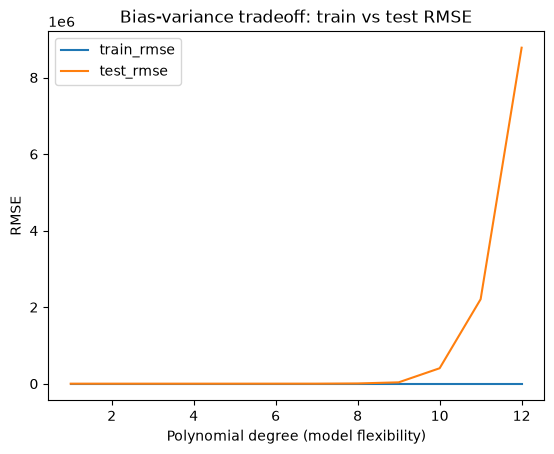

Best test score at degree: 1


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
x = np.linspace(0, 1, 200)
y_true = np.sin(2 * np.pi * x)
y = y_true + rng.normal(0, 0.25, size=x.size)

rows = []
for d in range(1, 13):
    coef = np.polyfit(x[:100], y[:100], d)
    train_rmse = np.sqrt(np.mean((np.polyval(coef, x[:100]) - y[:100]) ** 2))
    test_rmse = np.sqrt(np.mean((np.polyval(coef, x[100:]) - y[100:]) ** 2))
    rows.append({"degree": d, "train_rmse": train_rmse, "test_rmse": test_rmse})

df_poly = pd.DataFrame(rows).set_index("degree")
df_poly.plot()
plt.title("Bias-variance tradeoff: train vs test RMSE")
plt.ylabel("RMSE")
plt.xlabel("Polynomial degree (model flexibility)")
plt.show()
print("Best test score at degree:", df_poly["test_rmse"].idxmin())

## 2. Why Time-Series CV ≠ Random CV

A model for AQI uses **lag features** — yesterday's AQI, last week's AQI. A lag feature of a
smooth series carries information about *nearby-in-time* values. If we shuffle the rows and
split randomly, training rows and validation rows come from **interleaved periods of the same
series**, so validation looks deceptively easy: the model has effectively seen the future.

Walk-forward CV keeps time order: train only on the **past**, validate on the **future** —
exactly what happens in production.

Demo: a series with a **regime shift** in the middle. Random CV sees both regimes in training
and looks great; walk-forward only sees the past, so it honestly struggles after the shift.

In [2]:
# Autocorrelated series whose LEVEL shifts up at t=3000 (a new regime).
# The model predicts the next value from the current one (a lag-1 feature).
n = 4000
t = np.arange(n)
series = np.zeros(n)
for i in range(1, n):
    shift = 1.2 if i >= 3000 else 0.0  # regime shift: mean level jumps
    series[i] = 0.85 * series[i-1] + shift + rng.normal(0, 1.0)

X = series[:-1]  # feature: current value
ydata = series[1:]  # target: next value

def ols_rsq(Xtr, ytr, Xte, yte):
    A = np.column_stack([Xtr, np.ones_like(Xtr)])
    coef, *_ = np.linalg.lstsq(A, ytr, rcond=None)
    pred = np.column_stack([Xte, np.ones_like(Xte)]) @ coef
    ss_res = np.sum((yte - pred) ** 2)
    ss_tot = np.sum((yte - yte.mean()) ** 2)
    return 1 - ss_res / ss_tot

# Random CV (shuffled) — the WRONG way for time series: its training rows are
# sampled from BOTH regimes, so it has seen the future level in training.
perm = rng.permutation(len(ydata))
cut_r = int(0.8 * len(ydata))
tr, te = perm[:cut_r], perm[cut_r:]
random_rsq = ols_rsq(X[tr], ydata[tr], X[te], ydata[te])

# Walk-forward — the RIGHT way: trains ONLY on the pre-shift past (t < 3000),
# then must predict the post-shift future it has never seen.
cut = 3000
walkforward_rsq = ols_rsq(X[:cut], ydata[:cut], X[cut:], ydata[cut:])

print(f"Random CV      R² = {random_rsq:.4f}   (optimistic — training sampled from both regimes)")
print(f"Walk-forward   R² = {walkforward_rsq:.4f}   (honest — only the past, surprised by the shift)")

Random CV      R² = 0.9330   (optimistic — training sampled from both regimes)
Walk-forward   R² = 0.2515   (honest — only the past, surprised by the shift)


**This is why `src/features/targets.py` ships `walk_forward_split()`** and why every
model from Day 10 onward is scored through `walk_forward_evaluate()` in
`src/training/evaluate.py` — same folds, same metrics, apples-to-apples.

## 3. The Naive Baselines

- **Persistence:** tomorrow = today. `y_h(t) = us_aqi(t)`.
- **Seasonal naive:** the same hour one week before the *target* time. `y_h(t) = us_aqi(t + h - 168)` — always known at prediction time, so no leakage.

If a model can't beat these, it's not a model yet. Load the Feature Store (or demo data) and score them.

In [3]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "..")  # allow `import src.*` when running from notebooks/

from src.features.feature_store import get_feature_store
from src.features.targets import add_targets
from src.training.evaluate import evaluate_baselines, walk_forward_evaluate
from src.training.evaluate import persistence_predictions, seasonal_naive_predictions

df = get_feature_store().read_features()
if df.empty:
    print("Feature Store empty — using SYNTHETIC demo data.")
    print("Run the Day 8 backfill (python -m src.data_ingestion.historical_backfill) for real numbers.")
    from src.training.evaluate import _demo_data
    df = _demo_data()
else:
    # Store rows carry the event-time column; make it the index (hourly, ascending).
    df = df.set_index("date").sort_index()
    df["us_aqi"] = df["us_aqi"].astype(float)

print(f"Data: {df.shape[0]} rows, {df['city'].nunique()} cities, {df.index.min()} -> {df.index.max()}")
df.head()

2026-08-04 17:15:46,939 | INFO | src.features.feature_store | Using Parquet fallback feature store


2026-08-04 17:15:46,941 | WARNING | src.features.feature_store | No Parquet files found in /app/data/processed/feature_store_parquet


Feature Store empty — using SYNTHETIC demo data.
Run the Day 8 backfill (python -m src.data_ingestion.historical_backfill) for real numbers.
Data: 19200 rows, 2 cities, 2023-01-01 00:00:00 -> 2024-02-04 23:00:00


,city,us_aqi
2023-01-01 00:00:00,Karachi,83.656605
2023-01-01 00:00:00,Lahore,79.491765
2023-01-01 01:00:00,Lahore,89.008505
2023-01-01 01:00:00,Karachi,68.646093
2023-01-01 02:00:00,Karachi,91.255650


In [4]:
# Targets: y_24 / y_48 / y_72 = us_aqi at t+24h / +48h / +72h
target_cols = [f"y_{h}" for h in (24, 48, 72)]
if not set(target_cols).issubset(df.columns):
    df = add_targets(df)
else:
    print("Targets already present (written by the backfill).")

results = evaluate_baselines(df)
results

2026-08-04 17:15:47,013 | INFO | src.features.targets | Added targets ['y_24', 'y_48', 'y_72']: 19056 rows kept (144 tail rows dropped for incomplete targets)


2026-08-04 17:15:47,073 | INFO | src.training.evaluate | Evaluated 2 baselines x 3 horizons


,baseline,horizon_h,n,rmse,mae,r2
0,persistence,24,19056,25.027806,20.500563,0.141603
1,persistence,48,19056,37.325899,31.953218,-0.908818
2,persistence,72,19056,44.795845,38.909405,-1.740153
3,seasonal_naive,24,18768,17.078443,13.614799,0.596887
4,seasonal_naive,48,18816,17.094089,13.626234,0.595500
5,seasonal_naive,72,18864,17.091068,13.623575,0.596234


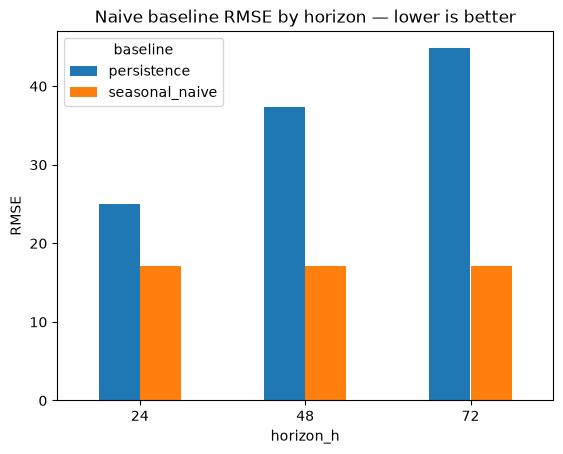

In [5]:
results.pivot(index="horizon_h", columns="baseline", values="rmse").plot(kind="bar")
plt.title("Naive baseline RMSE by horizon — lower is better")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.show()

## 4. The Harness Real Models Will Use (Day 10+)

`walk_forward_evaluate(df, fit_predict)` scores any model with the signature
`fit_predict(train_df, valid_df) -> predictions DataFrame`. Demo: plug the
stateless seasonal-naive baseline in as a stand-in "model" — this proves the
harness end-to-end before real models exist.

In [6]:
def seasonal_naive_model(train_df, valid_df):
    # Baselines are stateless: ignore train, look back inside valid_df.
    return seasonal_naive_predictions(valid_df)

wf = walk_forward_evaluate(df, seasonal_naive_model, n_splits=4)
wf.tail(6)  # last 3 rows = mean across folds per horizon

2026-08-04 17:15:47,359 | INFO | src.features.targets | Fold cut=2023-04-10 06:00:00: train 4764 rows, validate 14148 rows


2026-08-04 17:15:47,366 | INFO | src.features.targets | Fold cut=2023-06-15 09:00:00: train 7938 rows, validate 10974 rows


2026-08-04 17:15:47,375 | INFO | src.features.targets | Fold cut=2023-08-20 13:00:00: train 11114 rows, validate 7798 rows


2026-08-04 17:15:47,381 | INFO | src.features.targets | Fold cut=2023-10-25 17:00:00: train 14290 rows, validate 4622 rows


2026-08-04 17:15:47,478 | INFO | src.training.evaluate | Walk-forward evaluation: 4 folds, 3 horizons


,fold_cut,horizon_h,n,rmse,mae,r2
9,2023-10-25 17:00:00,24,4334.0,17.065180,13.638702,0.510427
10,2023-10-25 17:00:00,48,4382.0,17.132456,13.687541,0.504499
11,2023-10-25 17:00:00,72,4430.0,17.119204,13.675558,0.503637
12,mean,24,NaN,17.052519,13.603491,0.540319
13,mean,48,NaN,17.091325,13.631747,0.536754
14,mean,72,NaN,17.083821,13.625051,0.536788


## Takeaways — the numbers to beat

- The **baseline table above is the floor**. Any model that doesn't beat seasonal-naive
  RMSE at every horizon is not earning its keep.
- Expect skill to **decay with horizon** (+72h hardest) — that is a real, reportable finding (risk R10).
- From Day 10 on, every model goes through the **same** `walk_forward_evaluate()` harness:
  same folds, same metrics, comparable numbers.

Next: **Day 10 — Linear & Ridge regression** (`src/training/train.py`).